In [1]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


In [2]:
# !unzip -q '/content/gdrive/MyDrive/CV/lesson_2/Данные.zip' -d '/content/gdrive/MyDrive/CV/lesson_2/'

# Импорты

In [3]:
import os
import cv2
import PIL
import glob
import tqdm
import wandb
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F

import torchvision
import torchvision.models as models
import torchvision.transforms.v2 as transforms

from dataclasses import dataclass
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from torch.utils.data import Dataset, DataLoader

In [4]:
print(sorted(os.listdir('/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN')))
print(sorted(os.listdir('/content/gdrive/MyDrive/CV/lesson_2/signs/TEST')))

['.DS_Store', '0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '5', '6', '7', '8', '9']
['.DS_Store', '0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '5', '6', '7', '8', '9']


In [5]:
all_train_files = sorted(glob.glob('/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/*/*'))
all_test_files = sorted(glob.glob('/content/gdrive/MyDrive/CV/lesson_2/signs/TEST/*/*'))

In [6]:
print(all_train_files[: 10], len(all_train_files))
print(all_test_files[: 10], len(all_test_files))

['/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/0/000_0001.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/0/000_0002.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/0/000_0003.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/0/000_0004.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/0/000_0005.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/0/000_0006.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/0/000_0007.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/0/000_0008.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/0/000_0008_j.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TRAIN/0/000_0009.png'] 1792
['/content/gdrive/MyDrive/CV/lesson_2/signs/TEST/0/000_0001_j.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TEST/0/000_0002_j.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TEST/0/000_0003_j.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TEST/0/000_0004_j.png', '/content/gdrive/MyDrive/CV/lesson_2/signs/TEST/0/000_0005_j.pn

In [7]:
train_classes = [int(x.split('/')[-2]) for x in all_train_files]
test_classes = [int(x.split('/')[-2]) for x in all_test_files]

In [8]:
train_df = pd.DataFrame(zip(all_train_files, train_classes), columns=['im_name', 'class'])
test_df = pd.DataFrame(zip(all_test_files, test_classes), columns=['im_name', 'class'])

In [9]:
train_df

,im_name,class
0,/content/gdrive/MyDrive/CV/lesson_2/signs/TRAI...,0
1,/content/gdrive/MyDrive/CV/lesson_2/signs/TRAI...,0
2,/content/gdrive/MyDrive/CV/lesson_2/signs/TRAI...,0
3,/content/gdrive/MyDrive/CV/lesson_2/signs/TRAI...,0
4,/content/gdrive/MyDrive/CV/lesson_2/signs/TRAI...,0
...,...,...
1787,/content/gdrive/MyDrive/CV/lesson_2/signs/TRAI...,9
1788,/content/gdrive/MyDrive/CV/lesson_2/signs/TRAI...,9
1789,/content/gdrive/MyDrive/CV/lesson_2/signs/TRAI...,9
1790,/content/gdrive/MyDrive/CV/lesson_2/signs/TRAI...,9


In [10]:
counts_train = train_df.groupby('class')['im_name'].count().reset_index()
counts_test = test_df.groupby('class')['im_name'].count().reset_index()

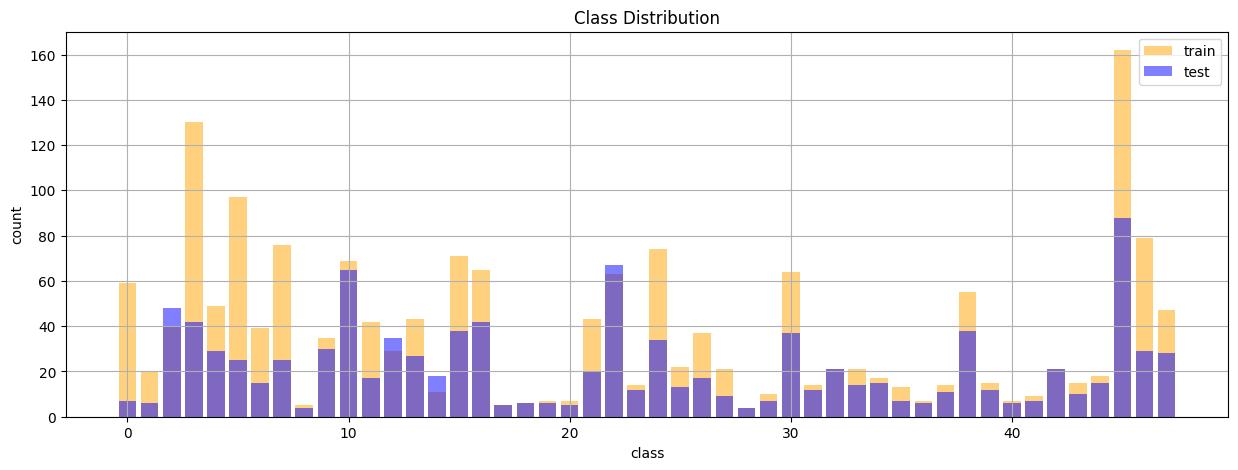

In [11]:
plt.figure(figsize=(15, 5))
plt.xlabel('class')
plt.ylabel('count')
plt.title('Class Distribution')
plt.bar(counts_train['class'], counts_train['im_name'], color='orange', alpha=0.5, label='train')
plt.bar(counts_test['class'], counts_test['im_name'], color='blue', alpha=0.5, label='test')
plt.legend()
plt.grid()
plt.show()

# DataSet и DataLoader

In [12]:
# Функция для включения детерминированности в PyTorch
def enable_determinism():
    # Устанавливаем переменную окружения для конфигурации рабочего пространства cuBLAS
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    # Используем детерминированные алгоритмы в PyTorch
    torch.use_deterministic_algorithms(True)

# Функция для фиксации начальных значений генераторов случайных чисел
def fix_seeds(seed):
    # Фиксируем начальное значение для генератора случайных чисел NumPy
    np.random.seed(seed)
    # Фиксируем начальное значение для генератора случайных чисел Python
    random.seed(seed)
    # Фиксируем начальное значение для генератора случайных чисел PyTorch на CPU
    torch.manual_seed(seed)
    # Фиксируем начальное значение для генератора случайных чисел PyTorch на GPU
    torch.cuda.manual_seed(seed)

# Функция для фиксации начальных значений генераторов случайных чисел в рабочих процессах DataLoader
def seed_worker(_):
    # Получаем начальное значение для рабочего процесса
    worker_seed = torch.initial_seed() % 2**32
    # Фиксируем начальное значение для генератора случайных чисел NumPy
    np.random.seed(worker_seed)
    # Фиксируем начальное значение для генератора случайных чисел Python
    random.seed(worker_seed)

In [13]:
@dataclass
class Config:
    seed: int = 42

    batch_size: int = 32
    img_size: int = 64

    n_epochs: int = 10
    lr: float = 1e-4


config = Config()
enable_determinism()
fix_seeds(config.seed)

In [14]:
generator = torch.Generator()
generator.manual_seed(config.seed)

In [15]:
class SignDataset(data.Dataset):
    def __init__(self, dataframe, transform=None):
        """
        Инициализация набора данных.

        :param dataframe: DataFrame, содержащий пути к изображениям и соответствующие метки.
        :param transform: Опциональный параметр для преобразования изображений.
        """
        self.imlist = dataframe  # Сохраняем DataFrame с путями к изображениям и метками
        self.transform = transform  # Сохраняем функцию преобразования изображений, если она предоставлена

    def __getitem__(self, index):
        """
        Получение элемента набора данных по индексу.

        :param index: Индекс элемента в наборе данных.
        :return: Преобразованное изображение, метка и путь к изображению.
        """
        impath, target = self.imlist.loc[index]  # Получаем путь к изображению и метку по индексу

        # Проверяем существование файла по указанному пути
        if not os.path.exists(impath):
            print('No file', impath)  # Выводим сообщение, если файл не существует
            pass  # Пропускаем текущую итерацию, если файл не найден

        # Открываем изображение и преобразуем его в формат RGB
        img = PIL.Image.open(impath).convert('RGB')

        # Применяем преобразование к изображению, если оно предоставлено
        if self.transform:
            img = self.transform(img)

        # Возвращаем преобразованное изображение, метку и путь к изображению
        return img, target, impath

    def __len__(self):
        """
        Возвращает количество элементов в наборе данных.

        :return: Количество элементов в наборе данных.
        """
        return len(self.imlist)  # Возвращаем длину DataFrame, которая соответствует количеству изображений

In [16]:
# Определяем последовательность преобразований для изображений
transform = transforms.Compose([
    # Изменяем размер изображения до 64x64 пикселей с антиалиасингом
    transforms.Resize((64, 64), antialias=True),
    # Преобразуем изображение PIL в тензор
    transforms.PILToTensor(),
    # Преобразуем тензор в тип данных float32 и масштабируем значения пикселей в диапазон [0, 1]
    transforms.ToDtype(dtype=torch.float32, scale=True),
    # Нормализуем тензор с использованием средних значений и стандартных отклонений для каждого канала
    transforms.Normalize([0.3, 0.3, 0.3], [0.3, 0.3, 0.3])
])

# Создаем объекты датасетов для обучения и тестирования
train_dataset = SignDataset(dataframe=train_df, transform=transform)
test_dataset = SignDataset(dataframe=test_df, transform=transform)

# Создаем DataLoader для обучающего датасета
train_loader = DataLoader(
    train_dataset,  # Датасет для обучения
    batch_size=32,  # Размер батча
    num_workers=8,  # Количество рабочих процессов для загрузки данных
    shuffle=True,   # Перемешивание данных
    pin_memory=True,  # Использование закрепленной памяти для более быстрой загрузки данных
    drop_last=True,  # Игнорирование последнего батча, если он меньше указанного размера
    worker_init_fn=seed_worker,  # Функция инициализации рабочих процессов для фиксации начальных значений
    generator=generator  # Генератор для детерминированного порядка данных
)

# Создаем DataLoader для тестового датасета
test_loader = DataLoader(
    test_dataset,  # Датасет для тестирования
    batch_size=32,  # Размер батча
    num_workers=8,  # Количество рабочих процессов для загрузки данных
    pin_memory=True,  # Использование закрепленной памяти для более быстрой загрузки данных
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [17]:
# функция для разнормализации картинки и ее отрисовки
def myshow(img):
    img = img * 0.3 + 0.3
    npimg = img.detach().numpy()
    fig = plt.figure(figsize=(10, 10))
    plt.imshow(npimg.transpose(1, 2, 0))

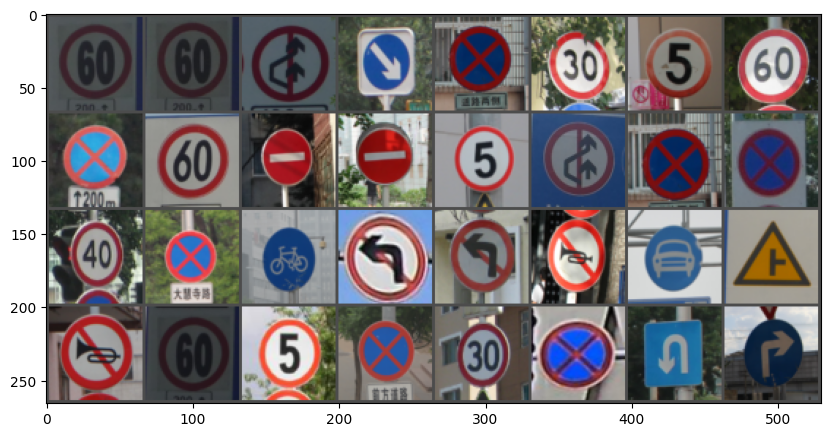

In [18]:
images, labels, impaths = next(iter(train_loader))
myshow(torchvision.utils.make_grid(images))

# Train model

In [19]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device: {device}')

Device: cuda


In [31]:
# Единая функция для обучения и для оценки (eval)
def run_epoch(epoch, net, loader, criterion, optimizer, device, is_train):
    # Устанавливаем режим модели в зависимости от того, обучаемся мы или оцениваем
    if is_train:
        net.train()  # Включаем режим обучения
    else:
        net.eval()  # Включаем режим оценки

    running_loss = 0.0  # Накапливаемая потеря
    correct = 0.0  # Количество правильных предсказаний
    total = 0.0  # Общее количество предсказаний
    all_preds = []  # Список всех предсказаний
    all_labels = []  # Список всех меток

    # Итерируемся по батчам данных
    for i, data in tqdm.tqdm(enumerate(loader)):
        images, labels, _ = data  # Разбиваем данные на изображения и метки
        images, labels = images.to(device), labels.to(device)  # Перемещаем данные на устройство (CPU/GPU)

        outputs = net(images)  # Получаем выходные данные модели
        loss = criterion(outputs, labels)  # Вычисляем потерю

        if is_train:
            optimizer.zero_grad()  # Обнуляем градиенты
            loss.backward()  # Выполняем обратное распространение ошибки
            optimizer.step()  # Обновляем веса модели

        running_loss += loss.item()  # Накапливаем потерю
        _, predicted = torch.max(outputs.data, 1)  # Получаем предсказанные классы

        all_preds = np.concatenate((all_preds, predicted.cpu().numpy()))  # Сохраняем предсказания
        all_labels = np.concatenate((all_labels, labels.cpu().numpy()))  # Сохраняем метки

    acc = (all_preds == all_labels).sum() / len(all_preds)  # Вычисляем точность
    bal_acc = balanced_accuracy_score(all_labels, all_preds)  # Вычисляем сбалансированную точность

    # Выводим метрики
    print('Loss: {:.3f}, accuracy: {:.3f}, balanced_accuracy: {:.3f}'.format(running_loss / (i + 1), acc * 100, bal_acc * 100))

    # Логируем метрики в wandb
    if is_train:
        wandb.log({'train_loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'train_accuracy': acc * 100}, step=epoch)
        wandb.log({'train_balanced_accuracy': bal_acc * 100}, step=epoch)
    else:
        wandb.log({'test_loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'test_accuracy': acc * 100}, step=epoch)
        wandb.log({'test_balanced_accuracy': bal_acc * 100}, step=epoch)

## ResNet 50 дообучение FC

In [21]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)
train_params = [v for k, v in net.named_parameters() if k in {'fc.weight', 'fc.bias'}]

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 134MB/s]


In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(train_params, lr=config.lr)

In [23]:
wandb.init(
    project='lesson-2',
    name='finetune_resnet_50',
    config=config.__dict__
)

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


In [24]:
fix_seeds(config.seed)

for epoch in range(config.n_epochs):
    # train
    print(f'Training epochs: {epoch + 1} / {config.n_epochs}')
    run_epoch(epoch, net, train_loader, criterion, optimizer, device, is_train=True)

    # eval
    print(f'Validation')
    with torch.no_grad():
        run_epoch(epoch, net, test_loader, criterion, optimizer, device, is_train=False)

    print('-----------------------------')

print('Finished')
wandb.finish()

Training epochs: 1 / 10
Loss: 3.671, accuracy: 10.826, balanced_accuracy: 6.516
Validation


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Loss: 3.617, accuracy: 10.806, balanced_accuracy: 5.699
-----------------------------
Training epochs: 2 / 10


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Loss: 3.265, accuracy: 27.679, balanced_accuracy: 13.449
Validation


...

Loss: 2.658, accuracy: 36.209, balanced_accuracy: 23.349
-----------------------------
Training epochs: 10 / 10


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Loss: 1.829, accuracy: 74.219, balanced_accuracy: 51.256
Validation


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Loss: 2.702, accuracy: 36.588, balanced_accuracy: 24.239
-----------------------------
Finished


## Дообучение всей модели ResNet50

In [26]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)

In [32]:
wandb.init(
    project='lesson-2',
    name='train_full_resnet_50',
    config=config.__dict__
)

fix_seeds(config.seed)

for epoch in (range(config.n_epochs)):
    # train
    print(f'Training epochs: {epoch + 1} / {config.n_epochs}')
    run_epoch(epoch, net, train_loader, criterion, optimizer, device, is_train=True)

    # eval
    print(f'Validation')
    with torch.no_grad():
        run_epoch(epoch, net, test_loader, criterion, optimizer, device, is_train=False)

    print('-----------------------------')

print('Finished')
wandb.finish()

Training epochs: 1 / 10


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
56it [00:09,  6.14it/s]

Loss: 0.051, accuracy: 99.219, balanced_accuracy: 98.149
Validation



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
8it [00:01,  7.48it/s]wandb: WARNING Tried to log to step 0 that is less than the current step 2. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 0 that is less than the current step 2. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 0 that is less than the current step 2. Steps must be monotonically incr

Loss: 0.779, accuracy: 79.336, balanced_accuracy: 73.562
-----------------------------
Training epochs: 2 / 10


...


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
56it [00:07,  7.20it/s]

Loss: 0.002, accuracy: 100.000, balanced_accuracy: 100.000
Validation



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
33it [00:04,  7.34it/s]

Loss: 0.647, accuracy: 82.938, balanced_accuracy: 78.499
-----------------------------
Finished


test_accuracy,▁▄▇▇▇█████
test_balanced_accuracy,▁▄▇▇▇█████
test_loss,█▄▂▁▁▁▁▁▁▁
train_accuracy,▁▆████████
train_balanced_accuracy,▁▄████████
train_loss,█▃▁▁▁▁▁▁▁▁
test_accuracy,82.93839
test_balanced_accuracy,78.49896
test_loss,0.64742
train_accuracy,100
train_balanced_accuracy,100
